In [6]:
pip install xgboost

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.comNote: you may need to restart the kernel to use updated packages.

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 2.8 MB/s eta 0:00:37
    --------------------------------------- 1.8/101.7 MB 5.0 MB/s eta 0:00:20
   - -------------------------------------- 3.1/101.7 MB 5.4 MB/s eta 0:00:19
   - -------------------------------------- 4.7/101.7 MB 5.8 MB/s eta 0:00:17
   -- ------------------------------------- 6.0/101.7 MB 6.0 MB/s eta 0:00:17
   -- ------------------------------------- 7.3/101.7 MB 6.0 MB/s eta 0:00:16
   --- ------------------------------------ 8.7/101.7 MB 6.0 MB/s eta 0:00:16
   --- ------------------------------------ 10.0/101.7 MB 6.0 MB/s eta 0:00:16
   ---- ----------------------------------- 11.0/101.7 MB 6.0 MB/s eta 0:00:16
   ---- ----------------------------------- 12.3/101.7 MB 5.9 MB/s eta 0:00:16
   ----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tensorboard 2.10.1 requires google-auth-oauthlib<0.5,>=0.4.1, but you have google-auth-oauthlib 1.2.4 which is incompatible.
tensorboard 2.10.1 requires protobuf<3.20,>=3.9.2, but you have protobuf 3.20.2 which is incompatible.
tensorflow 2.19.0 requires keras>=3.5.0, but you have keras 2.10.0 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 3.20.2 which is incompatible.
tensorflow 2.19.0 requires tensorboard~=2.19.0, but you have tensorboard 2.1

In [17]:
# Gerekli Kütüphanelerin Yüklenmesi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
warnings.filterwarnings('ignore')

In [18]:
# 1. Veriyi Yükleme
# (Eğer dosyan farklı bir klasördeyse yolunu ona göre güncelle)
df = pd.read_csv('04_master_table.csv')

# 2. Hızlı Veri Kontrolü
print("Veri Seti Boyutu:", df.shape)
print("-" * 30)
print(df.info())
print("-" * 30)


Veri Seti Boyutu: (4319, 7)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4319 entries, 0 to 4318
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_pseudo_id       4319 non-null   object
 1   traffic_source       2919 non-null   object
 2   d3_total_events      4319 non-null   int64 
 3   d3_levels_completed  4319 non-null   int64 
 4   d3_errors            4319 non-null   int64 
 5   d3_max_score         4319 non-null   int64 
 6   target_roas_d30      4319 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 236.3+ KB
None
------------------------------



--- 30. Gün Satın Alma Durumu (Target) ---
                 Kullanıcı Sayısı  Yüzde (%)
target_roas_d30                             
0                            4304      99.65
1                              15       0.35


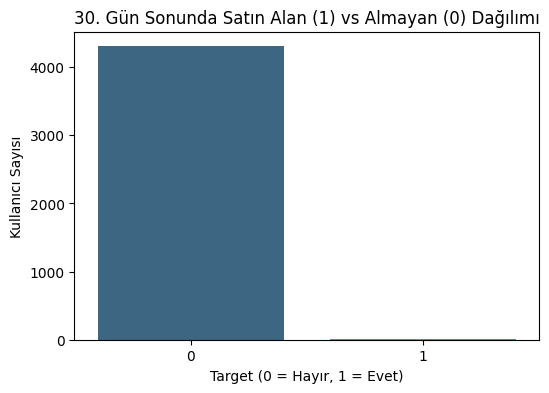

In [19]:
# 3. Null Değerlerin İşlenmesi (Data Cleaning)
# traffic_source null ise 'Unknown' yapalım, diğer numeric null'ları 0 yapalım
df['traffic_source'].fillna('Unknown', inplace=True)
df.fillna(0, inplace=True)

# 4. Hedef Değişkenin (Target) Dağılımına Bakalım (Kritik Aşama!)
target_counts = df['target_roas_d30'].value_counts()
target_percentages = df['target_roas_d30'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Kullanıcı Sayısı': target_counts,
    'Yüzde (%)': target_percentages.round(2)
})

print("\n--- 30. Gün Satın Alma Durumu (Target) ---")
print(summary_df)

# Görselleştirme
plt.figure(figsize=(6, 4))
sns.countplot(x='target_roas_d30', data=df, palette='viridis')
plt.title('30. Gün Sonunda Satın Alan (1) vs Almayan (0) Dağılımı')
plt.ylabel('Kullanıcı Sayısı')
plt.xlabel('Target (0 = Hayır, 1 = Evet)')
plt.show()

# Model Building 

In [21]:
# 1. Yeni veriyi yüklediğini varsayıyorum (df)
# Eğer hala CSV kullanıyorsan: df = pd.read_csv('yeni_4300_veri.csv')

# 2. Temizlik ve Encoding
df_model = df.drop('user_pseudo_id', axis=1)
df_model['traffic_source'].fillna('Unknown', inplace=True)
df_model = pd.get_dummies(df_model, columns=['traffic_source'], drop_first=True)

X = df_model.drop('target_roas_d30', axis=1)
y = df_model['target_roas_d30']

# 3. Stratified Split (1'lerin dağıldığından emin olalım)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Yeni Ağırlık Hesaplama
pos_count = y_train.sum()
neg_count = len(y_train) - pos_count
weight = neg_count / pos_count
print(f"Yeni Pozitif Örnek Sayısı: {pos_count}")
print(f"Yeni scale_pos_weight: {weight:.2f}")

# 5. Model Parametrelerini İyileştirme (Tuning)
xgb_final = XGBClassifier(
    scale_pos_weight=weight,
    learning_rate=0.01,       # Daha yavaş ama daha derin öğrenme
    n_estimators=500,         # Daha fazla ağaç
    max_depth=5,              # Biraz daha derin ağaçlar
    subsample=0.8,            # Verinin %80'ini rastgele seçerek eğitmesini sağlamak
    colsample_bytree=0.8,     # Özelliklerin %80'ini seç
    random_state=42,
    eval_metric='aucpr'
)

xgb_final.fit(X_train, y_train)
y_pred = xgb_final.predict(X_test)

# 6. Rapor
print("\n--- YENİ SINIFLANDIRMA RAPORU ---")
print(classification_report(y_test, y_pred))

Yeni Pozitif Örnek Sayısı: 12
Yeni scale_pos_weight: 286.92

--- YENİ SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       861
           1       0.00      0.00      0.00         3

    accuracy                           0.97       864
   macro avg       0.50      0.48      0.49       864
weighted avg       0.99      0.97      0.98       864



In [23]:
# Basit bir ROAS (Return on Ad Spend) Simülasyonu
ads_spent_per_user = 5  # Tahmin ettiğimiz her '1' için harcanan para
revenue_per_buyer = 50  # Gerçekten alan birinin bıraktığı para

target_users = confusion_matrix(y_test, y_pred)[0][1] + confusion_matrix(y_test, y_pred)[1][1] # Modelin '1' dediği herkes
actual_buyers_found = confusion_matrix(y_test, y_pred)[1][1] # Modelin doğru bildiği alıcılar

total_cost = target_users * ads_spent_per_user
total_revenue = actual_buyers_found * revenue_per_buyer

print(f"Toplam Reklam Harcaması: {total_cost}$")
print(f"Toplam Elde Edilen Gelir: {total_revenue}$")
if total_cost > 0:
    print(f"ROAS Skoru: {total_revenue / total_cost:.2f}")
else:
    print("Model hiç kimseyi hedeflemedi.")

Toplam Reklam Harcaması: 130$
Toplam Elde Edilen Gelir: 0$
ROAS Skoru: 0.00
